In [1]:
import numpy as np
from ephys_dimension_reduction_CD import coding_direction_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions

sessions = find_ephys_sessions()
failed_sessions = []

binsize = "0.1"
align = "go_cue"
projection_time_window = None     # None => full peri-event time
two_fold_cv = True                # use the swap split as well
norm_mode = "divide_sqrtN"        # {"none","divide_sqrtN","unit_variance_fit","zscore_fit"}

time_windows = [[0.3, 2], [-1, 0]]
trial_types = ["right_choice_trials","left_choice_trials"]

for session in sessions[2]:
    try:
        psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
        df = smart_read_csv(f"/root/capsule/scratch/behavior_summary-{session}.csv")

        # Pull trial-id arrays and clean up (drop NaN, cast to int)
        def _clean_ids(x):
            arr = np.asarray(x[0])
            arr = arr[~np.isnan(arr)] if arr.dtype.kind in {"f"} else arr
            return arr.astype(int)

        typeA_ids = _clean_ids(df[trial_types[0]])
        typeB_ids = _clean_ids(df[trial_types[1]])

        for time_window in time_windows:
            save_path = (
                f"/root/capsule/scratch/CD_{session}_{trial_types[0]}_{trial_types[1]}"
                f"_timewindow_{time_window[0]}_{time_window[1]}.zarr"
            )

            out = coding_direction_from_psth(
                psth_da=psth_da,
                trial_ids_typeA=typeA_ids,
                trial_ids_typeB=typeB_ids,
                align=align,
                time_window=tuple(time_window),
                projection_time_window=projection_time_window,
                random_state=0,
                two_fold_cv=two_fold_cv,
                norm_mode=norm_mode,
                save_path=save_path,
                save_format="zarr",
                overwrite=True,
            )

            # Prefer the returned path if the function decides/changes it
            print(f"Finished: {out.get('saved_to', save_path)}")

    except Exception as e:
        print(f"❌ Error in session {session}: {e}")
        failed_sessions.append(session)

print("\nAll sessions done.")
if failed_sessions:
    print("Failed sessions:")
    for s in failed_sessions:
        print(f" - {s}")
else:
    print("No errors 🎉")


❌ Error in session ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753125_2024-10-14_15-37-15_sorted_2024-11-09_20-07-38: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753125_2024-10-15_16-16-22_sorted_2024-11-09_19-57-50: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753126_2024-10-10_17-51-24_sorted_2025-02-21_13-56-40: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753126_2024-10-11_13-14-24_sorted_2024-11-09_19-18-21: name 'extract_trial_unit_timecube' is not defined
❌ Error in session ecephys_753126_2024-10-15_12-20-35_sorted_2024-11-09_19-4

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Literal
from scipy.ndimage import gaussian_filter1d, uniform_filter1d

def plot_cd_projection(
    time: np.ndarray,
    trace_A: np.ndarray,
    trace_B: np.ndarray,
    *,
    average: bool = True,
    sem: bool = True,
    smooth: Optional[float] = None,
    smooth_mode: Literal["gaussian", "moving"] = "gaussian",
    dt: Optional[float] = None,
    edge_handling: Literal["reflect", "nearest", "mirror", "wrap", "none"] = "reflect",
    labels: Tuple[str, str] = ("Type A", "Type B"),
    colors: Tuple[str, str] = ("#1f77b4", "#d62728"),
    figsize: Tuple[int, int] = (6, 4),
    alpha_single: float = 0.15,
    linewidth_mean: float = 2.0,
    xlim: Optional[Tuple[float, float]] = None,
    ylim: Optional[Tuple[float, float]] = None,
    title: Optional[str] = None,
    xlabel: str = "Time (s)",
    ylabel: str = "Projection along CD",
) -> None:
    """
    Plot coding-direction projection traces for two trial types (A vs B),
    with optional temporal smoothing and robust edge handling.

    Parameters
    ----------
    smooth : float or None
        If >0, smoothing window. Interpreted in *seconds* if `dt` is provided,
        otherwise in *samples*.
    smooth_mode : {'gaussian','moving'}
        Gaussian kernel (softer) or moving average (boxcar).
    dt : float or None
        Sample spacing (sec). Needed only if `smooth` is in seconds.
    edge_handling : {'reflect','nearest','mirror','wrap','none'}
        How to treat edges when smoothing. 'reflect' (default) avoids boundary artefacts.
        If 'none', no padding is used; instead the plot is trimmed to the valid region.
    """
    def _kernel_pts():
        if smooth is None or smooth <= 0:
            return 0
        return max(1, int(round((smooth if dt is None else smooth / dt))))

    def _smooth_traces(tr: np.ndarray) -> Tuple[np.ndarray, Optional[slice]]:
        k = _kernel_pts()
        if k <= 1:
            return tr, None

        if smooth_mode == "gaussian":
            # Use reflect to avoid ramps/flattening at the ends
            tr_sm = gaussian_filter1d(tr, sigma=k, axis=-1, mode=("nearest" if edge_handling=="none" else edge_handling), truncate=3.0)
            if edge_handling == "none":
                # Trim ~3*sigma samples from both ends (valid region)
                trim = int(3.0 * k)
                sl = slice(trim, tr.shape[-1]-trim)
                tr_sm = tr_sm[..., sl]
                return tr_sm, sl
            return tr_sm, None

        elif smooth_mode == "moving":
            if edge_handling == "none":
                # Valid-only convolution: use cumulative-sum trick and trim ends
                w = k
                # boxcar via cumulative sum (valid window only)
                def _boxcar_valid(x):
                    c = np.cumsum(np.pad(x, (1,0), mode="constant"))
                    y = (c[w:] - c[:-w]) / w
                    return y
                sm = np.apply_along_axis(_boxcar_valid, -1, tr)
                sl = slice(k//2, tr.shape[-1] - (k - 1 - k//2))
                return sm, sl
            else:
                tr_sm = uniform_filter1d(tr, size=k, axis=-1, mode=edge_handling)
                return tr_sm, None
        else:
            raise ValueError("smooth_mode must be 'gaussian' or 'moving'.")

    # Smooth A/B (and get any trimming slices if edge_handling=='none')
    trace_A_sm, slA = _smooth_traces(trace_A)
    trace_B_sm, slB = _smooth_traces(trace_B)

    # If we trimmed, align time to the valid region
    time_plot = time
    if slA is not None or slB is not None:
        # Use intersection of valid slices
        def _to_slice(s, n):
            return s if s is not None else slice(0, n)
        n = time.shape[0]
        sA = _to_slice(slA, n); sB = _to_slice(slB, n)
        start = max(sA.start, sB.start)
        stop  = min(sA.stop,  sB.stop)
        sl = slice(start, stop)
        trace_A_sm = trace_A_sm[..., slA.start - start: slA.start - start + (stop-start)]
        trace_B_sm = trace_B_sm[..., slB.start - start: slB.start - start + (stop-start)]
        time_plot = time[sl]

    fig, ax = plt.subplots(figsize=figsize)

    def _plot_group(traces, color, label):
        if average:
            mean = np.nanmean(traces, axis=0)
            if sem:
                err = np.nanstd(traces, axis=0) / np.sqrt(max(1, traces.shape[0]))
                ax.fill_between(time_plot, mean - err, mean + err, color=color, alpha=0.25, lw=0)
            ax.plot(time_plot, mean, color=color, lw=linewidth_mean, label=label)
        else:
            # faint single trials + thick mean on top
            for tr in traces:
                ax.plot(time_plot, tr, color=color, alpha=alpha_single, lw=1.0)
            ax.plot(time_plot, np.nanmean(traces, axis=0), color=color, lw=linewidth_mean, label=label)

    _plot_group(trace_A_sm, colors[0], labels[0])
    _plot_group(trace_B_sm, colors[1], labels[1])

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    if title: ax.set_title(title)
    ax.legend(frameon=False)
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


In [10]:
import os
import xarray as xr
import numpy as np
import re
import pandas as pd
from general_utils import smart_read_csv
    
base_dir='/root/capsule/scratch/'
session='ecephys_764787_2024-12-11_15-01-15_sorted_2025-02-21_17-11-57'
end_with='_right_choice_trials_left_choice_trials_timewindow_-1_0'

df = smart_read_csv(f"{base_dir}/behavior_summary-{session}.csv")
ds = xr.open_zarr(f"{base_dir}/CD_{session}{end_with}.zarr", consolidated=False)




In [13]:
import numpy as np

# Flatten the list from your dataframe
trial_ids_typeA = df[trial_types[0]].values[0]

# Check if all test-A IDs are contained in that list
contained = np.isin(trial_id_train_A, trial_ids_typeA).all()
print("All test-A IDs are contained:", contained)

# If not, show which ones are missing
if not contained:
    missing = trial_id_train_A[~np.isin(trial_id_train_A, trial_ids_typeA)]
    print("Missing IDs:", missing)


All test-A IDs are contained: True


In [ ]:
df

,session_id,ForagingCompareThreshold-deltaQ,ForagingCompareThreshold-deltaQ-1,ForagingCompareThreshold-deltaQ+1,ForagingCompareThreshold-sumQ,ForagingCompareThreshold-sumQ-1,ForagingCompareThreshold-sumQ+1,ForagingCompareThreshold-right_choice_probability,ForagingCompareThreshold-right_choice_probability-1,ForagingCompareThreshold-right_choice_probability+1,...,switch_trial_reward_trials,switch_trial_noreward_trials,switch_LR_trials,switch_LR_reward_trials,switch_LR_noreward_trials,switch_RL_trials,switch_RL_reward_trials,switch_RL_noreward_trials,left_choice_trials,right_choice_trials
0,764787_2024-12-11_15-01-15,NaN,NaN,NaN,NaN,NaN,NaN,"[0.5, 0.25779183727082133, 0.21151885026834905...","[0.0, 0.5, 0.25779183727082133, 0.211518850268...","[0.25779183727082133, 0.21151885026834905, 0.1...",...,"[25, 59, 69, 98, 148, 157, 181, 187, 190, 210,...","[27, 41, 60, 151, 189, 211, 232, 233, 410]","[25, 59, 69, 148, 157, 187, 190, 211, 226, 232...","[25, 59, 69, 148, 157, 187, 190, 226, 238, 347...","[211, 232]","[27, 41, 60, 98, 151, 181, 189, 210, 212, 227,...","[98, 181, 210, 212, 227, 372, 390, 479, 484]","[27, 41, 60, 151, 189, 233, 410]","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[25, 26, 40, 59, 69, 70, 71, 72, 73, 74, 75, 7..."


In [12]:
import numpy as np

# Flatten the list from your dataframe
trial_all = df['left_choice_trials'].values[0]
trial_part= df['switch_RL_trials'].values[0]
# Check if all test-A IDs are contained in that list
contained = np.isin(trial_part, trial_all).all()
print("All test-A IDs are contained:", contained)

# If not, show which ones are missing
if not contained:
    missing = trial_id_test_A[~np.isin(trial_id_test_A, trial_ids_typeA)]
    print("Missing IDs:", missing)


All test-A IDs are contained: True


Train A  (LR / RL): 17 / 0
Train B  (LR / RL): 0 / 16
Test  A  (LR / RL): 17 / 0
Test  B  (LR / RL): 0 / 16


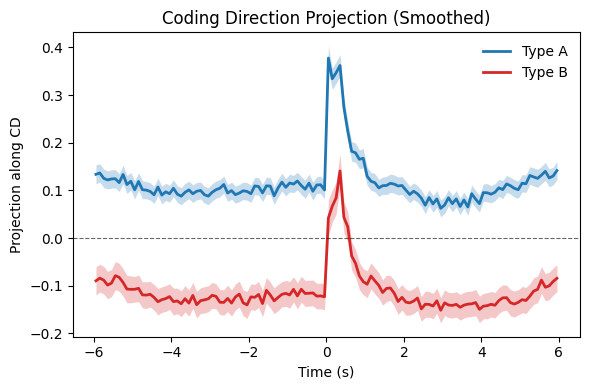

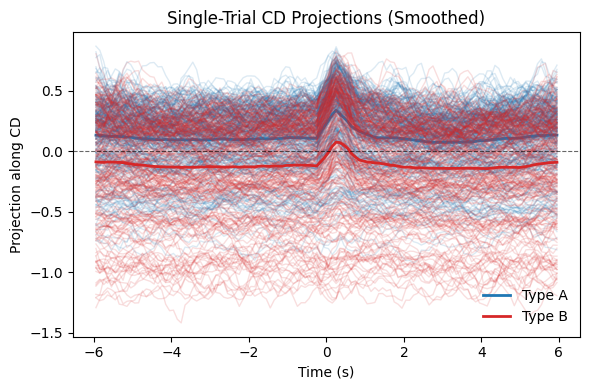

In [11]:
import numpy as np

time = ds["time"].values

# --- Load and clean trial IDs ---
switch_LR = np.asarray(df["switch_LR_trials"][0], dtype=int)
switch_RL = np.asarray(df["switch_RL_trials"][0], dtype=int)

trial_id_test_A = np.asarray(ds["trial_id_test_A"].values, dtype=int)
trial_id_test_B = np.asarray(ds["trial_id_test_B"].values, dtype=int)
trial_id_train_A = np.asarray(ds["trial_id_train_A"].values, dtype=int)
trial_id_train_B = np.asarray(ds["trial_id_train_B"].values, dtype=int)

proj_train_A = ds["projection_trace_train_A"].values
proj_train_B = ds["projection_trace_train_B"].values
proj_test_A = ds["projection_trace_test_A"].values
proj_test_B = ds["projection_trace_test_B"].values

# --- Helper function ---
def select_traces_by_switch(proj, trial_ids, switch_ids):
    mask = np.isin(trial_ids, switch_ids)
    return proj[mask], trial_ids[mask]

# --- Train set ---
proj_train_A_LR, trial_train_A_LR = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_LR)
proj_train_A_RL, trial_train_A_RL = select_traces_by_switch(proj_train_A, trial_id_train_A, switch_RL)

proj_train_B_LR, trial_train_B_LR = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_LR)
proj_train_B_RL, trial_train_B_RL = select_traces_by_switch(proj_train_B, trial_id_train_B, switch_RL)

# --- Test set ---
proj_test_A_LR, trial_test_A_LR = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_LR)
proj_test_A_RL, trial_test_A_RL = select_traces_by_switch(proj_test_A, trial_id_test_A, switch_RL)

proj_test_B_LR, trial_test_B_LR = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_LR)
proj_test_B_RL, trial_test_B_RL = select_traces_by_switch(proj_test_B, trial_id_test_B, switch_RL)

# --- Summary printout ---
print("Train A  (LR / RL):", proj_train_A_LR.shape[0], "/", proj_train_A_RL.shape[0])
print("Train B  (LR / RL):", proj_train_B_LR.shape[0], "/", proj_train_B_RL.shape[0])
print("Test  A  (LR / RL):", proj_test_A_LR.shape[0], "/", proj_test_A_RL.shape[0])
print("Test  B  (LR / RL):", proj_test_B_LR.shape[0], "/", proj_test_B_RL.shape[0])



proj_A=proj_test_A
proj_B=proj_test_B
# If your time vector is in seconds:
dt = np.mean(np.diff(time))

# Plot smoothed mean ± SEM (Gaussian, 100 ms)
plot_cd_projection(
    time, proj_A, proj_B,
    average=True, sem=True,
    smooth=0.1, dt=dt, smooth_mode="gaussian",
    title="Coding Direction Projection (Smoothed)"
)

# Or plot all single-trial traces with mild moving average smoothing
plot_cd_projection(
    time, proj_A, proj_B,
    average=False,
    smooth=5, smooth_mode="moving",   # smooth 10 points
    title="Single-Trial CD Projections (Smoothed)"
)
